In [40]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from itertools import combinations
from scipy.stats import wasserstein_distance

In [33]:
years_list = ["2015", "2016", "2017", "2018", "2019", "2022", "2023", "2024", "2025"]

In [34]:
wp_arrs_all = {}
avg_wp = {}
for szn in years_list:
    # load in df with all win prob combinations
    win_prob_df = pd.read_csv("../input_data/final_pairs_final.csv").iloc[:, 1:].copy()
    win_prob_df = win_prob_df.loc[win_prob_df["season"]==int(szn)]

    # create array for team, team win probabilities
    df = win_prob_df.drop(columns=["season"], errors="ignore").sort_values("cur_team")

    idx_cols = [c for c in df.columns if c not in ["opponent", "win_prob"]]

    win_prob_wide = (
        df.pivot_table(
            index=idx_cols,
            columns="opponent",
            values="win_prob",
            aggfunc="first"
        )
        .reset_index()
    ).sort_values("cur_team").sort_index(axis=1).drop("cur_team", axis=1)


    wp_arr_orig = np.nan_to_num(win_prob_wide.to_numpy(dtype=float))

    str_szn = str(szn)

    wp_arrs_all[str_szn] = wp_arr_orig

    avg_wp[str_szn] = list(wp_arrs_all[str_szn].mean(axis=0))
    avg_wp[str_szn].sort(reverse=True)

In [35]:
avg_wp_df = pd.DataFrame(avg_wp)

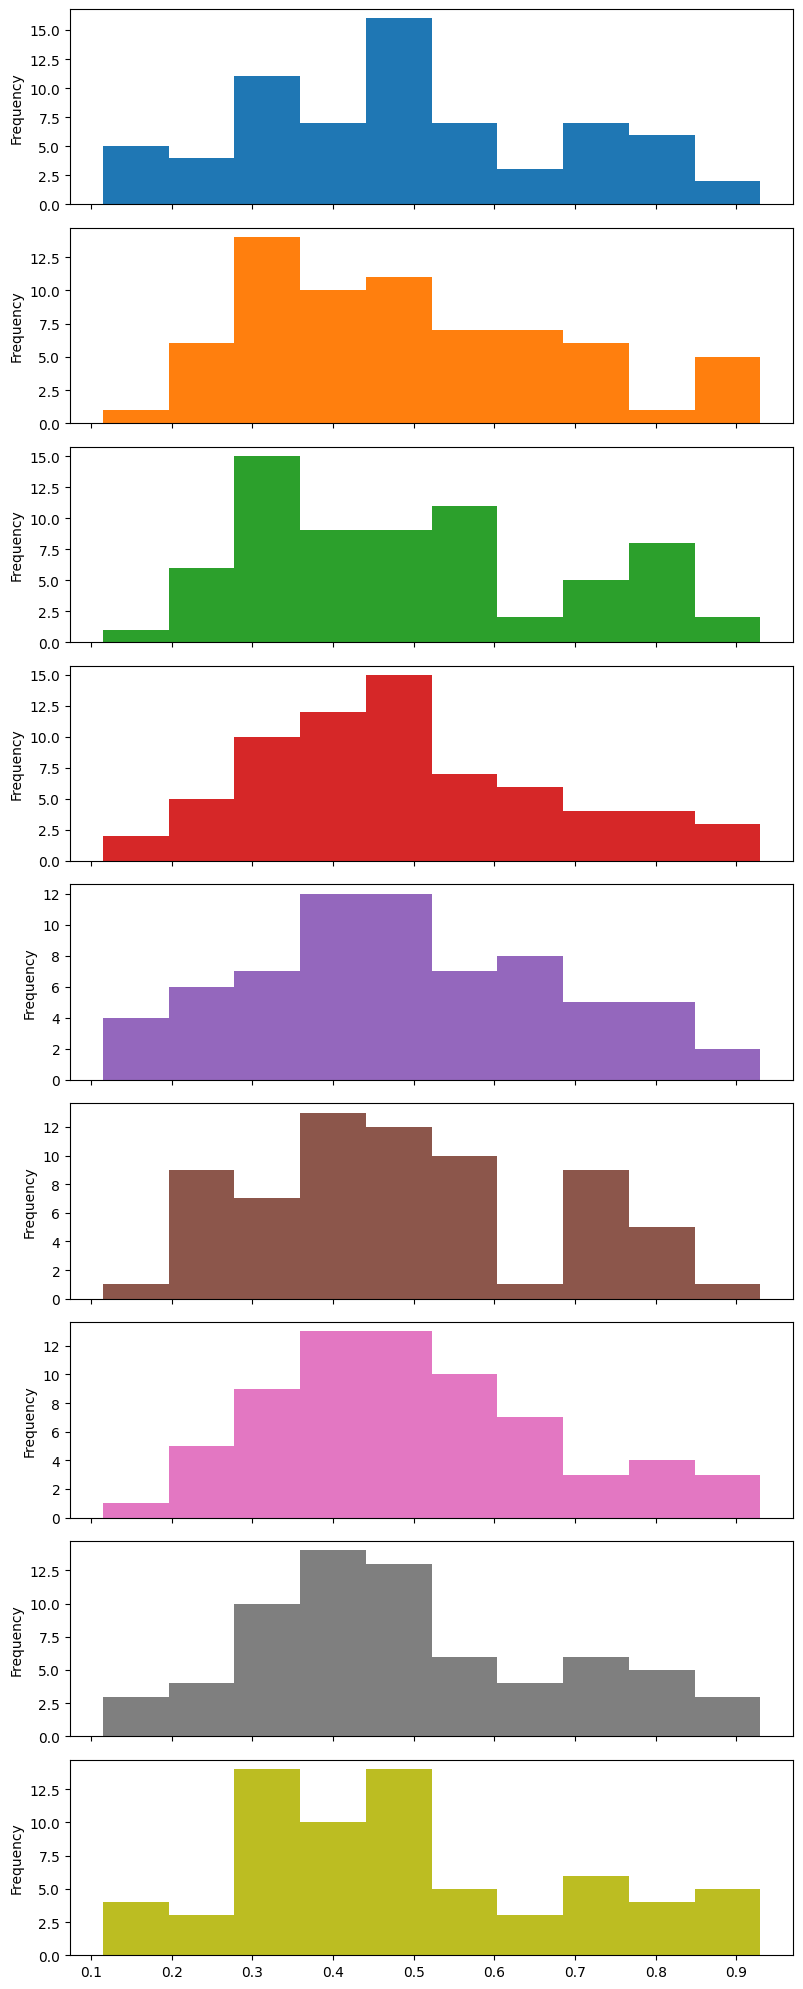

In [39]:
avg_wp_df[years_list].plot(
    kind="hist",
    bins=10,
    subplots=True,
    layout=(9, 1),
    figsize=(8, 20),
    legend=False
)

plt.tight_layout()
plt.show()

In [43]:
year_cols = avg_wp_df.columns

results = []

for y1, y2 in combinations(year_cols, 2):
    x1 = avg_wp_df[y1].dropna()
    x2 = avg_wp_df[y2].dropna()
    
    dist = wasserstein_distance(x1, x2)
    
    results.append({
        "year_1": y1,
        "year_2": y2,
        "wasserstein_distance": dist
    })

dist_df = pd.DataFrame(results).sort_values("wasserstein_distance").reset_index(drop=True)

print(dist_df)

   year_1 year_2  wasserstein_distance
0    2024   2025              0.012768
1    2018   2023              0.012870
2    2015   2019              0.015596
3    2016   2024              0.015810
4    2016   2018              0.016012
5    2016   2025              0.016510
6    2017   2024              0.016783
7    2018   2019              0.016787
8    2015   2025              0.016801
9    2016   2017              0.016848
10   2018   2022              0.016952
11   2015   2024              0.017095
12   2018   2024              0.017850
13   2017   2025              0.017948
14   2019   2024              0.017981
15   2018   2025              0.018140
16   2015   2017              0.018489
17   2015   2018              0.018945
18   2022   2023              0.019262
19   2016   2023              0.019423
20   2017   2022              0.019726
21   2016   2019              0.019971
22   2015   2022              0.020335
23   2019   2022              0.022209
24   2017   2018         